# Modelamiento Econometrico de Series de Tiempo
### Webinar Gratuito
## Quantmetrics
# !Impulsa tu futuro con el poder Quant!
## Docente: Jean Taipe

---
## Modelo ARIMA con Predicción

En este notebook desarrollaremos:
- Descarga de datos económicos desde FRED
- Análisis exploratorio
- Fundamentos teóricos del modelo ARIMA
- Identificación (ACF y PACF)
- Estimación
- Predicción dinámica
- Visualización interactiva

Notebook generado automáticamente el 2026-02-28

## 1. Fundamento Teórico

Un modelo ARIMA(p,d,q) se define como:

$$
\phi(B)(1 - B)^d y_t = \theta(B) \varepsilon_t
$$

Donde:
- $\phi(B)$ → componente autorregresiva (AR)
- $d$ → grado de diferenciación
- $\theta(B)$ → componente de medias móviles (MA)
- $\varepsilon_t$ → ruido blanco


In [ ]:
# Instalación

In [ ]:
 !pip install pandas_datareader statsmodels plotly --quiet

In [36]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pandas_datareader import data as web
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## 2. Descarga de Datos (FRED)
Usaremos la tasa de desempleo de EE.UU. (UNRATE).

In [37]:
df = web.DataReader('UNRATE', data_source='fred', start='1995-01-01')
df = df.dropna()
df

,UNRATE
DATE,
1995-01-01,5.6
1995-02-01,5.4
1995-03-01,5.4
1995-04-01,5.8
1995-05-01,5.6
...,...
2025-08-01,4.3
2025-09-01,4.4
2025-11-01,4.5


In [38]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['UNRATE'], mode='lines', name='Unemployment Rate'))
fig.update_layout(title='Serie Temporal - Tasa de Desempleo',
                  xaxis_title='Fecha',
                  yaxis_title='Tasa (%)')
fig.show()

## 3. Test de Estacionariedad (ADF)

In [39]:
adf_test = sm.tsa.stattools.adfuller(df['UNRATE'])
print('ADF Statistic:', adf_test[0])
print('p-value:', adf_test[1])

ADF Statistic: -3.1504531019866353
p-value: 0.02303782599431372


## 4. Diferenciación

In [41]:
df_diff = df.diff().dropna()
df_diff

,UNRATE
DATE,
1995-02-01,-0.2
1995-03-01,0.0
1995-04-01,0.4
1995-05-01,-0.2
1995-06-01,0.0
...,...
2025-08-01,0.0
2025-09-01,0.1
2025-11-01,0.1


## 5. ACF y PACF

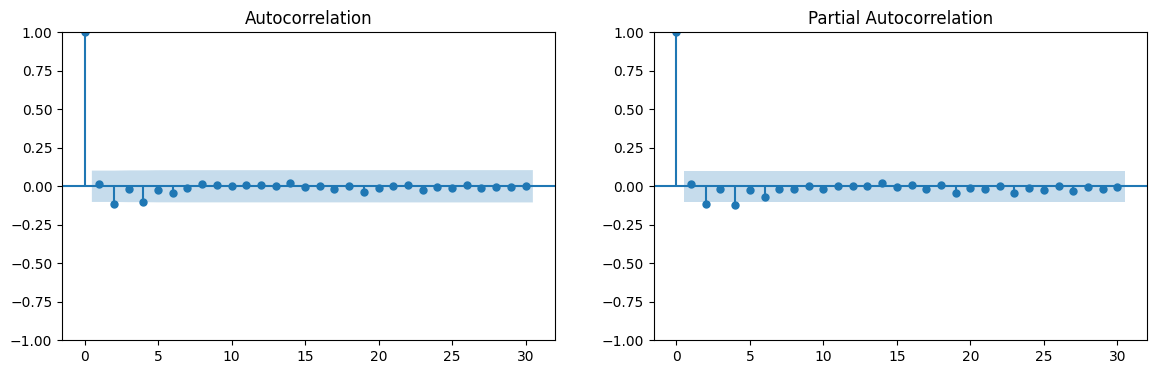

In [42]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
plot_acf(df_diff['UNRATE'], ax=axes[0], lags=30)
plot_pacf(df_diff['UNRATE'], ax=axes[1], lags=30)
plt.show()

## 6. Estimación ARIMA(1,1,1)

In [43]:
model = ARIMA(df['UNRATE'], order=(1,1,1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                 UNRATE   No. Observations:                  372
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -330.337
Date:                Sat, 28 Feb 2026   AIC                            666.674
Time:                        01:57:53   BIC                            678.422
Sample:                             0   HQIC                           671.340
                                - 372                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7208      0.135     -5.330      0.000      -0.986      -0.456
ma.L1          0.7934      0.129      6.153      0.000       0.541       1.046
sigma2         0.3474      0.002    144.772      0.0

## 7. Predicción Dinámica (12 meses)

In [44]:
forecast = results.get_forecast(steps=12)
forecast_df = forecast.summary_frame()
forecast_df

UNRATE,mean,mean_se,mean_ci_lower,mean_ci_upper
372,4.291580,0.589434,3.136311,5.446848
373,4.297649,0.864374,2.603508,5.991791
374,4.293274,1.052996,2.229441,6.357107
375,4.296428,1.223804,1.897817,6.695039
376,4.294155,1.366330,1.616197,6.972112
377,4.295793,1.500064,1.355721,7.235865
378,4.294612,1.619656,1.120145,7.469079
379,4.295464,1.733132,0.898588,7.692340
380,4.294850,1.838175,0.692093,7.897607
381,4.295292,1.938520,0.495862,8.094722


In [45]:
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=df.index, y=df['UNRATE'], mode='lines', name='Observado'))
fig2.add_trace(go.Scatter(x=forecast_index, y=forecast_df['mean'], mode='lines+markers', name='Pronóstico'))
fig2.add_trace(go.Scatter(x=forecast_index, y=forecast_df['mean_ci_lower'], mode='lines', name='IC Inferior', line=dict(dash='dash')))
fig2.add_trace(go.Scatter(x=forecast_index, y=forecast_df['mean_ci_upper'], mode='lines', name='IC Superior', line=dict(dash='dash')))
fig2.update_layout(title='Pronóstico ARIMA Dinámico',
                   xaxis_title='Fecha',
                   yaxis_title='Tasa (%)')
fig2.show()

## Conclusión
- ARIMA permite modelar dinámicas temporales económicas.
- La predicción dinámica facilita análisis prospectivo.
- Puede extenderse a inflación, tipo de cambio, PIB, etc.